In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rcParams["figure.dpi"] = 140
np.set_printoptions(precision=6, suppress=True)

In [2]:
# Normalized units:
# c = 1, omega_p = 1, k_p = omega_p / c = 1

C0 = 1.0
WP = 1.0


def sqrt_physical(z):
    """
    Complex square root with branch chosen so Im(root) >= 0.
    This is the usual decaying-wave choice for evanescent kz.
    Works for arrays.
    """
    z = np.asarray(z, dtype=np.complex128)
    out = np.sqrt(z)
    mask = np.imag(out) < 0
    out[mask] *= -1
    return out


def eps_drude_lossless(omega, wp=WP):
    """
    Lossless Drude model used in ref. [40]:
        eps(omega) = 1 - wp^2 / omega^2
    """
    omega = np.asarray(omega, dtype=np.complex128)
    return 1.0 - (wp**2) / (omega**2)


def rp_eq18_2d(omega, kx, beta, wp=WP, c=C0):
    r"""
    Explicit 2D moving-interface TM reflection coefficient from ref. [40], Eq. (18):
        rp(omega, kx) =
        [ eps(omega') kz - sqrt((eps(omega')-1) [gamma kx - gamma beta k0]^2 + eps(omega') kz^2 ) ]
        / 
        [ eps(omega') kz + sqrt((eps(omega')-1) [gamma kx - gamma beta k0]^2 + eps(omega') kz^2 ) ]

    with:
        k0 = omega/c
        kz = sqrt(k0^2 - kx^2)
        omega' = gamma (omega - beta c kx)

    This notebook uses the laboratory-frame convention of ref. [40],
    where the surface moves along +x.
    """
    gamma = 1.0 / np.sqrt(1.0 - beta**2)
    k0 = omega / c
    kz = sqrt_physical(k0**2 - kx**2 + 0j)

    omega_prime = gamma * (omega - beta * c * kx)
    eps = eps_drude_lossless(omega_prime, wp=wp)

    root_arg = (eps - 1.0) * (gamma * kx - gamma * beta * k0)**2 + eps * kz**2
    root = sqrt_physical(root_arg)

    num = eps * kz - root
    den = eps * kz + root
    return num / den

In [3]:
def compute_abs_rp_map(
    beta,
    omega_min=-2.0,
    omega_max=2.0,
    n_omega=801,
    kx_min=-4.0,
    kx_max=4.0,
    n_kx=1201,
    omega_avoid=1e-6,
):
    """
    Compute |rp| on a regular (omega, kx) grid.
    We avoid the exact omega=0 line by replacing zero with a tiny value,
    since the lossless Drude model is singular there.
    """
    omega_grid = np.linspace(omega_min, omega_max, n_omega)
    kx_grid = np.linspace(kx_min, kx_max, n_kx)

    abs_map = np.empty((n_omega, n_kx), dtype=float)

    for i, omega in enumerate(omega_grid):
        om = omega
        if abs(om) < omega_avoid:
            om = np.sign(om) * omega_avoid if om != 0 else omega_avoid

        rp = rp_eq18_2d(om, kx_grid, beta=beta)
        abs_map[i, :] = np.abs(rp)

    return omega_grid, kx_grid, abs_map

In [4]:
# Compute the two panels of ref. [40] Fig. 2
omega_grid, kx_grid, abs_rp_v0 = compute_abs_rp_map(beta=0.0)
_, _, abs_rp_v01 = compute_abs_rp_map(beta=0.1)

C:\Users\xtliang\AppData\Local\Temp\ipykernel_17832\2798124792.py:58: RuntimeWarning: invalid value encountered in divide
  return num / den
C:\Users\xtliang\AppData\Local\Temp\ipykernel_17832\2798124792.py:27: RuntimeWarning: divide by zero encountered in divide
  return 1.0 - (wp**2) / (omega**2)
C:\Users\xtliang\AppData\Local\Temp\ipykernel_17832\2798124792.py:27: RuntimeWarning: invalid value encountered in divide
  return 1.0 - (wp**2) / (omega**2)
C:\Users\xtliang\AppData\Local\Temp\ipykernel_17832\2798124792.py:15: RuntimeWarning: invalid value encountered in sqrt
  out = np.sqrt(z)


In [5]:
# Inspect dynamic range before plotting
print("v=0   : min, max =", abs_rp_v0.min(), abs_rp_v0.max())
print("v=0.1 : min, max =", abs_rp_v01.min(), abs_rp_v01.max())

v=0   : min, max = nan nan
v=0.1 : min, max = nan nan


In [6]:
# Use a shared logarithmic normalization across both panels.
# We exclude zeros and clamp the minimum to a small positive value.
all_positive = np.concatenate([abs_rp_v0.ravel(), abs_rp_v01.ravel()])
all_positive = all_positive[np.isfinite(all_positive)]
all_positive = all_positive[all_positive > 0]

vmin = max(np.percentile(all_positive, 1), 1e-6)
vmax = np.percentile(all_positive, 99.9)

print("LogNorm vmin =", vmin)
print("LogNorm vmax =", vmax)

LogNorm vmin = 0.022372711328520832
LogNorm vmax = 317.63966292457013


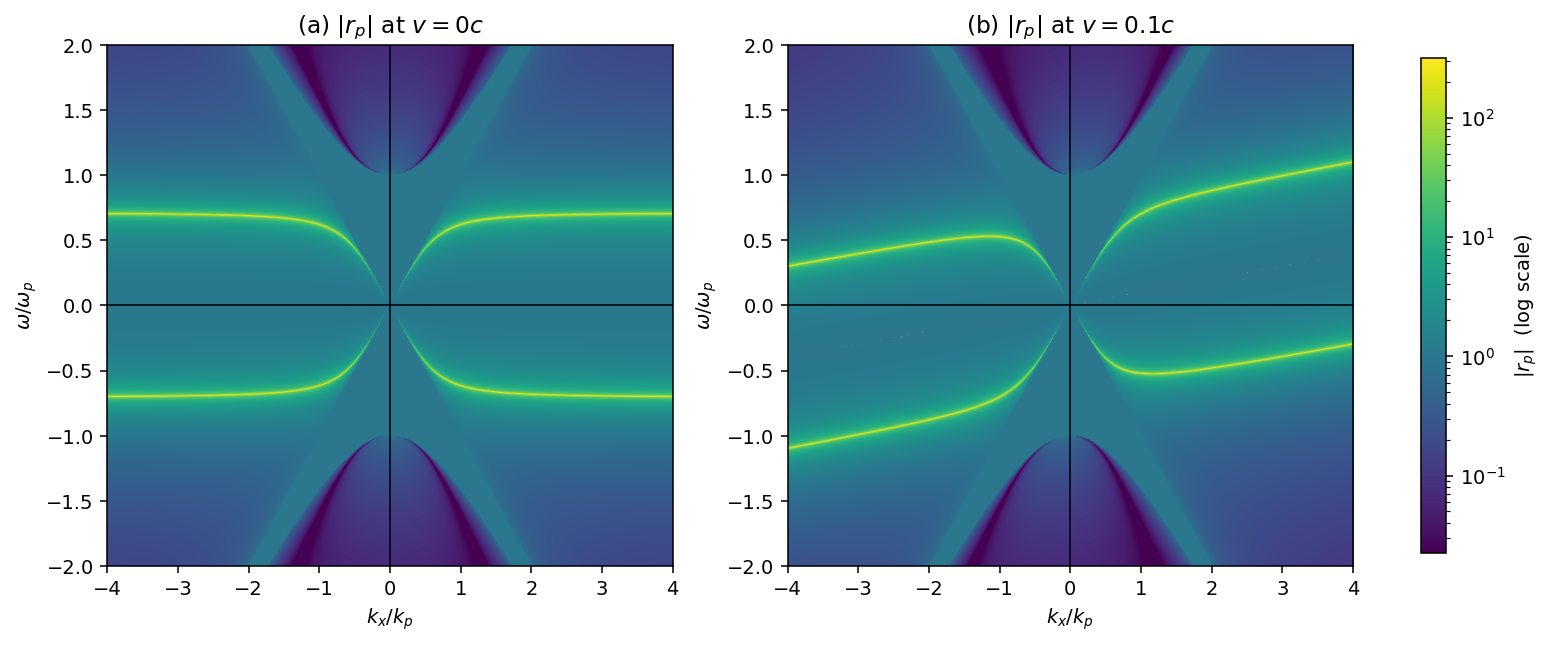

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

norm = LogNorm(vmin=vmin, vmax=vmax)

im0 = axes[0].imshow(
    abs_rp_v0,
    extent=[kx_grid.min(), kx_grid.max(), omega_grid.min(), omega_grid.max()],
    origin="lower",
    aspect="auto",
    norm=norm,
)
axes[0].set_title(r"(a) $|r_p|$ at $v=0c$")
axes[0].set_xlabel(r"$k_x/k_p$")
axes[0].set_ylabel(r"$\omega/\omega_p$")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].axvline(0, color="k", lw=0.8)

im1 = axes[1].imshow(
    abs_rp_v01,
    extent=[kx_grid.min(), kx_grid.max(), omega_grid.min(), omega_grid.max()],
    origin="lower",
    aspect="auto",
    norm=norm,
)
axes[1].set_title(r"(b) $|r_p|$ at $v=0.1c$")
axes[1].set_xlabel(r"$k_x/k_p$")
axes[1].set_ylabel(r"$\omega/\omega_p$")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].axvline(0, color="k", lw=0.8)

cbar = fig.colorbar(im1, ax=axes, shrink=0.95)
cbar.set_label(r"$|r_p|$  (log scale)")

plt.show()

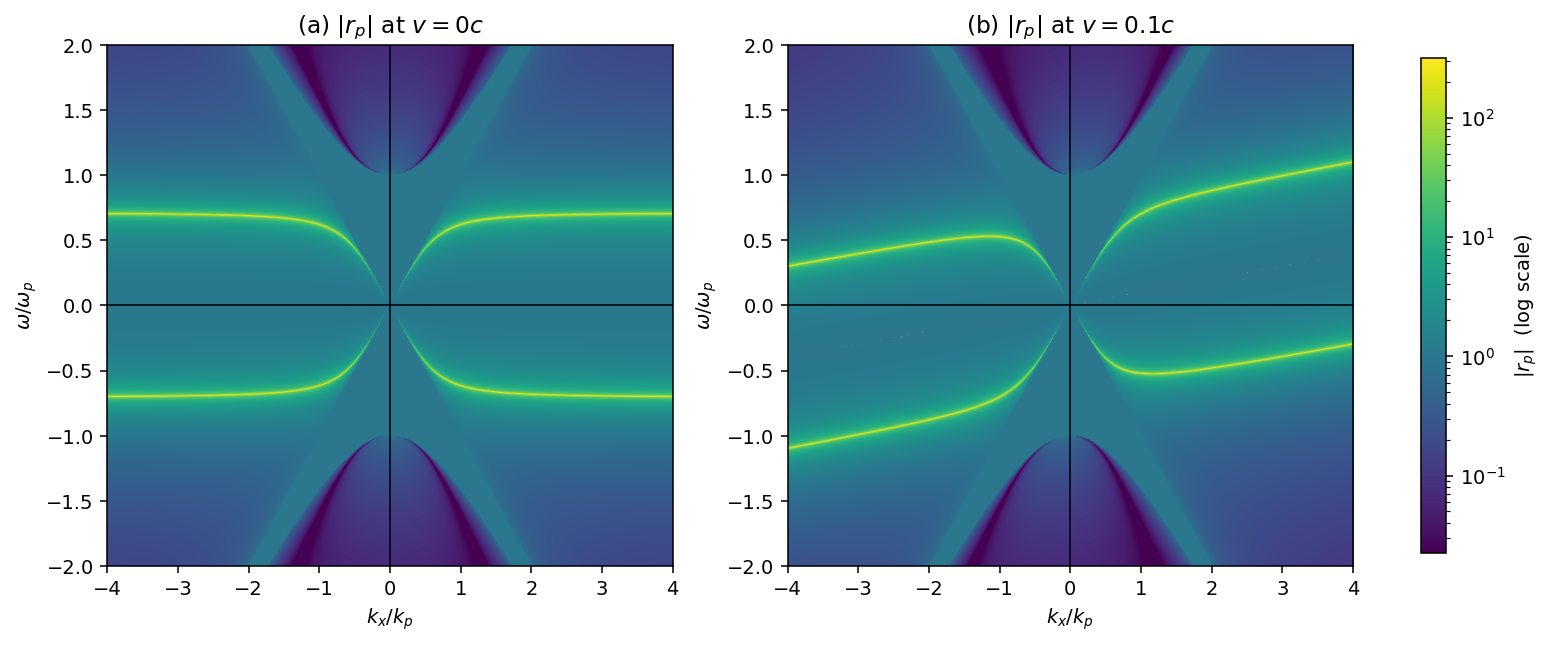

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

norm = LogNorm(vmin=vmin, vmax=vmax)
cmap = "viridis"  # you can also try "turbo" or "plasma"

for ax, data, title in [
    (axes[0], abs_rp_v0,  r"(a) $|r_p|$ at $v=0c$"),
    (axes[1], abs_rp_v01, r"(b) $|r_p|$ at $v=0.1c$"),
]:
    im = ax.imshow(
        data,
        extent=[kx_grid.min(), kx_grid.max(), omega_grid.min(), omega_grid.max()],
        origin="lower",
        aspect="auto",
        norm=norm,
        cmap=cmap,
    )
    ax.set_title(title)
    ax.set_xlabel(r"$k_x/k_p$")
    ax.set_ylabel(r"$\omega/\omega_p$")
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(0, color="k", lw=0.8)

cbar = fig.colorbar(im, ax=axes, shrink=0.95)
cbar.set_label(r"$|r_p|$  (log scale)")
plt.show()

In [9]:
def rp_rest_stationary(omega, kx, wp=WP, c=C0):
    k0 = omega / c
    kz0 = sqrt_physical(k0**2 - kx**2 + 0j)
    eps = eps_drude_lossless(omega, wp=wp)
    kzm = sqrt_physical(eps * k0**2 - kx**2 + 0j)
    return (eps * kz0 - kzm) / (eps * kz0 + kzm)

omega_test = 0.7
kx_test = np.linspace(-3, 3, 301)
err = np.max(np.abs(rp_eq18_2d(omega_test, kx_test, beta=0.0) - rp_rest_stationary(omega_test, kx_test)))
print("max error at beta=0:", err)

max error at beta=0: 1.3642420526593924e-12
